# Dynamic sparse JWST AMI calibration and binary inference

This tutorial calibrates a polynomial distortion of a genuinely sparse JWST/NIRISS
aperture mask, freezes the recovered geometry into a static sparse optic, and uses
that calibrated instrument to infer a close binary with Hamiltonian Monte Carlo.

In [1]:
import equinox as eqx
import jax
import jax.numpy as np
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax
import zodiax as zdx
from matplotlib.colors import CenteredNorm, PowerNorm
from numpyro.diagnostics import summary
from numpyro.infer import MCMC, NUTS
from tqdm.notebook import tqdm

import dLux as dl

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.family": "serif", "image.origin": "lower"})
cmaps = {"intensity": mpl.colormaps["inferno"], "residual": mpl.colormaps["seismic"]}


## Build a dynamic sparse mask

Each hole is sampled only on a compact local grid. `SparseDynamicOptic` applies a
shared polynomial coordinate distortion before localising the holes; propagation is
performed per hole and `Interfere` coherently combines their focal-plane fields.

In [2]:
local_grid = dl.GridSpec(n=32, diam=1.1, unit="m")
focal_grid = dl.GridSpec(n=40, d=25, unit="mas")
builder = dl.JWSTNRMLike(oversample=3)
distortion = dl.DistortCoords(order=2, shift_invariant=True)
injected = distortion.set(distortion=distortion.distortion.at[0, -1].set(0.015))


def make_system(transformation):
    pupil = dl.SparseDynamicOptic(
        builder.centers,
        transmission=builder.primary,
        transformation=transformation,
        normalise=False,
    )
    layers = [("pupil", pupil), ("focus", dl.Fraunhofer(focal_grid)), ("interfere", dl.Interfere())]
    return dl.OpticalSystem(grid=local_grid, layers=layers)


truth_optics = make_system(injected)
cal_source = dl.Source(wavelengths=4.3, flux=4.8, units={"wavelengths": "um", "flux": "log"})
truth_image = dl.Image(truth_optics.model(cal_source), read_noise=3.0)
calibration = truth_image.simulate(jr.key(0), n_frames=32)

## Recover the polynomial distortion

The calibration fits the polynomial coeffs themselves rather than seven
unrelated hole positions. A small regularisation term discourages unsupported large
higher-order mappings.

In [3]:
model_optics = make_system(distortion)
coeffs = model_optics.pupil.transformation.distortion


@eqx.filter_jit
@eqx.filter_value_and_grad
def calibration_loss(coeffs, optics, source, exposure):
    optics = optics.set("pupil.transformation.distortion", coeffs)
    prediction = optics.model(source)
    data_loss = np.mean(exposure.z_score(prediction) ** 2)
    return data_loss + 1e-4 * np.mean(coeffs**2)


optim = optax.sgd(2e-3, momentum=0.7)
state = optim.init(coeffs)
losses = []
for _ in tqdm(range(40)):
    loss, grads = calibration_loss(coeffs, model_optics, cal_source, calibration)
    updates, state = optim.update(grads, state)
    coeffs = optax.apply_updates(coeffs, updates)
    losses.append(loss)
recovered = model_optics.set("pupil.transformation.distortion", coeffs)

  0%|          | 0/40 [00:00<?, ?it/s]

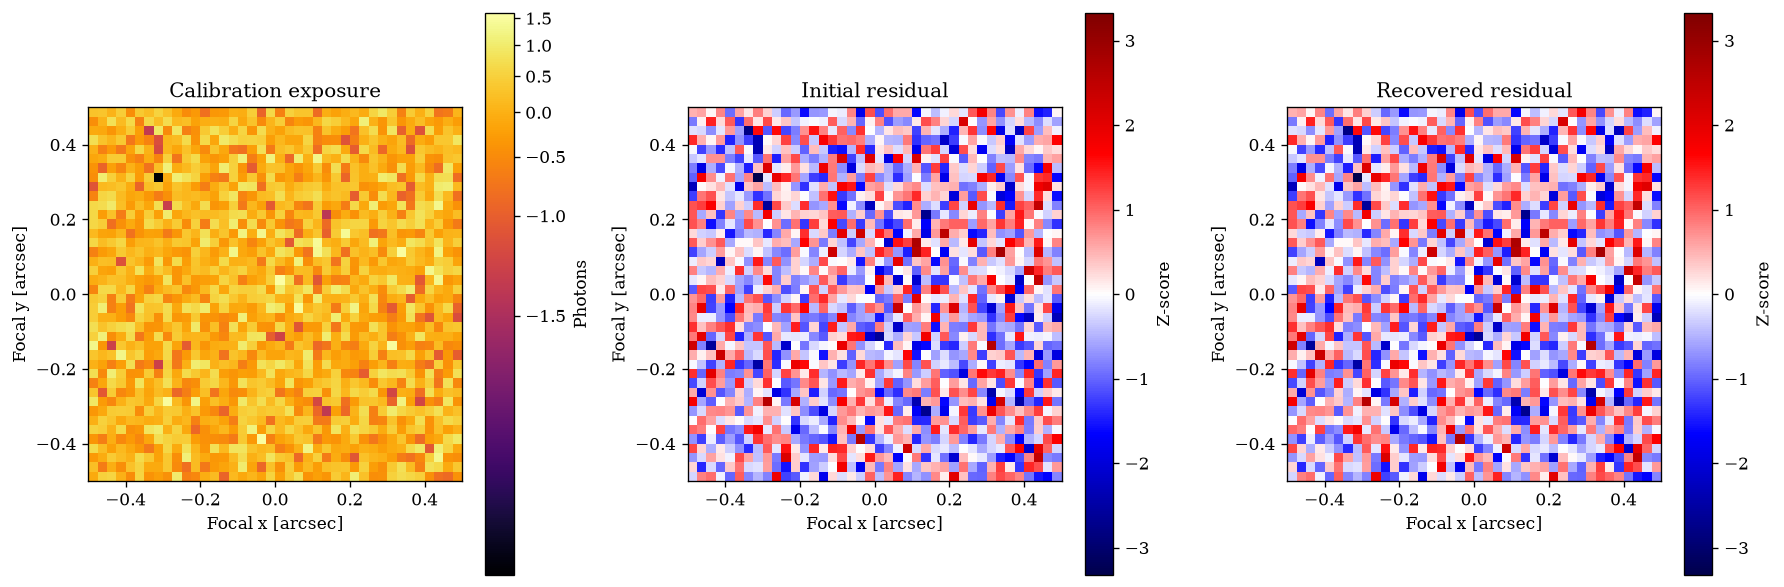

In [4]:
## COLLAPSE: Plotting code
start = model_optics.model(cal_source)
fit = recovered.model(cal_source)
extent = focal_grid.extent(ndim=2, unit="arcsec")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, data, title, cmap, norm in [
    (axes[0], calibration.data, "Calibration exposure", cmaps["intensity"], PowerNorm(0.3)),
    (axes[1], calibration.z_score(start), "Initial residual", cmaps["residual"], CenteredNorm()),
    (axes[2], calibration.z_score(fit), "Recovered residual", cmaps["residual"], CenteredNorm()),
]:
    im = ax.imshow(data, cmap, extent=extent, norm=norm)
    ax.set(title=title, xlabel="Focal x [arcsec]", ylabel="Focal y [arcsec]")
    fig.colorbar(im, ax=ax, label="Photons" if ax is axes[0] else "Z-score")
fig.tight_layout()
plt.show()

## Freeze the calibrated geometry

Evaluating the recovered mapping once produces calibrated hole centres for a static
`SparseOptic`. This compact export removes polynomial coordinate generation from the
later likelihood. A general distortion can also deform individual holes; this centre
export is appropriate for the small registration distortion injected here.

In [5]:
transform = recovered.pupil.transformation
centers = transform(builder.centers.T[:, :, None])[:, :, 0].T
static_pupil = dl.SparseOptic(centers, transmission=builder.primary, normalise=False)
static_optics = dl.OpticalSystem(
    grid=local_grid,
    layers=[("pupil", static_pupil), ("focus", dl.Fraunhofer(focal_grid)), ("interfere", dl.Interfere())],
)
dynamic_psf = recovered.model(cal_source)
static_psf = static_optics.model(cal_source)
agreement = np.linalg.norm(dynamic_psf.data - static_psf.data) / np.linalg.norm(dynamic_psf.data)
print(f"Dynamic/static relative image difference: {agreement:.3e}")

Dynamic/static relative image difference: 0.000e+00


## Infer a close binary with HMC

Sparse interferometric images can have strongly correlated and aliased binary-star
solutions. We therefore observe the same binary in three narrow wavelength channels:
the changing fringe scale supplies spectral diversity while all astrophysical
parameters remain shared.

Following the Zodiax HMC workflow, we first optimise a dimensionless parameter vector
to find a local maximum-likelihood solution. We then calculate a regularised
Gauss–Newton Hessian and use `zdx.eigen_projection` to map a near-unit latent vector
onto the correlated physical parameter space. HMC is a posterior sampler rather than
an optimiser; separating these stages gives NUTS a well-scaled local posterior to
explore.


In [6]:
# Simulate one binary observed in three narrow wavelength channels
binary = dl.BinarySource(
    wavelengths=4.3,
    centre=np.array([8.0, -5.0]),
    separation=65.0,
    position_angle=0.8,
    contrast=0.35,
    flux=8.0,
    units={"wavelengths": "um", "position": "mas", "flux": "log"},
)
wavelengths = np.array([3.8, 4.3, 4.8])
keys = jr.split(jr.key(2), len(wavelengths))
images = [
    dl.Image(static_optics.model(binary.set(wavelengths=w)), read_noise=1.0)
    for w in wavelengths
]
exposures = [image.simulate(key, n_frames=64) for image, key in zip(images, keys)]
data = np.stack([exposure.data for exposure in exposures])
error = np.stack([exposure.error for exposure in exposures])

# Define a scaled coordinate system and map it onto the source parameters
offset = np.array([62.0, 0.75, np.log(0.4), 7.95, 6.0, -3.0])
scale = np.array([3.0, 0.05, 0.1, 0.025, 1.0, 1.0])


def unpack(values):
    values = offset + scale * values
    return {
        "separation": values[0],
        "position_angle": values[1],
        "contrast": np.exp(values[2]),
        "flux": values[3],
        "centre": values[4:],
    }


def model_fn(values):
    source = binary.set(unpack(values))
    propagate = lambda w: static_optics.model(source.set(wavelengths=w)).data
    return eqx.filter_vmap(propagate)(wavelengths)


@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(values):
    return np.mean(zdx.z_score(model_fn(values), data, error) ** 2)


# Find a local maximum-likelihood solution before sampling
values = np.zeros(6)
optim = optax.adam(5e-3)
state = optim.init(values)
losses = []
for _ in tqdm(range(1000)):
    loss, grads = loss_fn(values)
    updates, state = optim.update(grads, state)
    values = optax.apply_updates(values, updates)
    losses.append(loss)

mle = unpack(values)
print("Final mean squared z-score:", float(loss))
print("Maximum-likelihood parameters:", mle)


  0%|          | 0/1000 [00:00<?, ?it/s]

Final mean squared z-score: 1.0423235893249512
Maximum-likelihood parameters: {'separation': Array(56.399086, dtype=float32), 'position_angle': Array(0.8103035, dtype=float32), 'contrast': Array(0.32771492, dtype=float32), 'flux': Array(7.9998083, dtype=float32), 'centre': Array([ 7.2009516, -5.9597406], dtype=float32)}


In [7]:
# Calculate and regularise the local Gauss-Newton Hessian
residual_fn = lambda value: zdx.z_score(model_fn(value), data, error).ravel()
jacobian = jax.jacfwd(residual_fn)(values)
hessian = jacobian.T @ jacobian
eigvals, eigvecs = np.linalg.eigh(hessian)
eigvals = np.maximum(eigvals, 1e-6 * eigvals.max())
hessian = (eigvecs * eigvals) @ eigvecs.T
projection = zdx.eigen_projection(fmat=hessian)


def project(latent):
    return values + projection @ latent


def posterior_model():
    latent = numpyro.sample("latent", dist.Uniform(-5, 5).expand((6,)))
    prediction = model_fn(project(latent))
    numpyro.sample("data", dist.Normal(prediction, error).to_event(3), obs=data)


# Run two independent chains and retain diagnostics for explicit validation
kernel = NUTS(posterior_model, target_accept_prob=0.9)
sampler = MCMC(
    kernel,
    num_warmup=200,
    num_samples=400,
    num_chains=2,
    chain_method="sequential",
    progress_bar=True,
)
sampler.run(jr.key(3))
sampler.print_summary()

chain_samples = sampler.get_samples(group_by_chain=True)["latent"]
diagnostics = summary({"latent": chain_samples}, group_by_chain=True)["latent"]
divergences = sampler.get_extra_fields(group_by_chain=True)["diverging"].sum()
print("Divergences:", int(divergences))
print("Maximum split R-hat:", float(np.max(diagnostics["r_hat"])))


sample: 100%|██████████| 600/600 [00:25<00:00, 23.30it/s, 31 steps of size 1.56e-01. acc. prob=0.92]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
 latent[0]     -0.68      2.51     -0.85     -4.96      3.11    279.01      1.01
 latent[1]      0.44      2.50      0.45     -3.25      4.77    340.09      1.01
 latent[2]     -2.91      0.95     -2.93     -4.40     -1.21    291.71      1.01
 latent[3]     -0.91      0.96     -0.91     -2.35      0.70    344.30      1.00
 latent[4]      0.63      0.98      0.62     -0.93      2.34    266.78      1.00
 latent[5]      0.48      2.05      0.47     -3.18      3.77    199.09      1.00

Number of divergences: 0
Divergences: 0
Maximum split R-hat: 1.0124446153640747


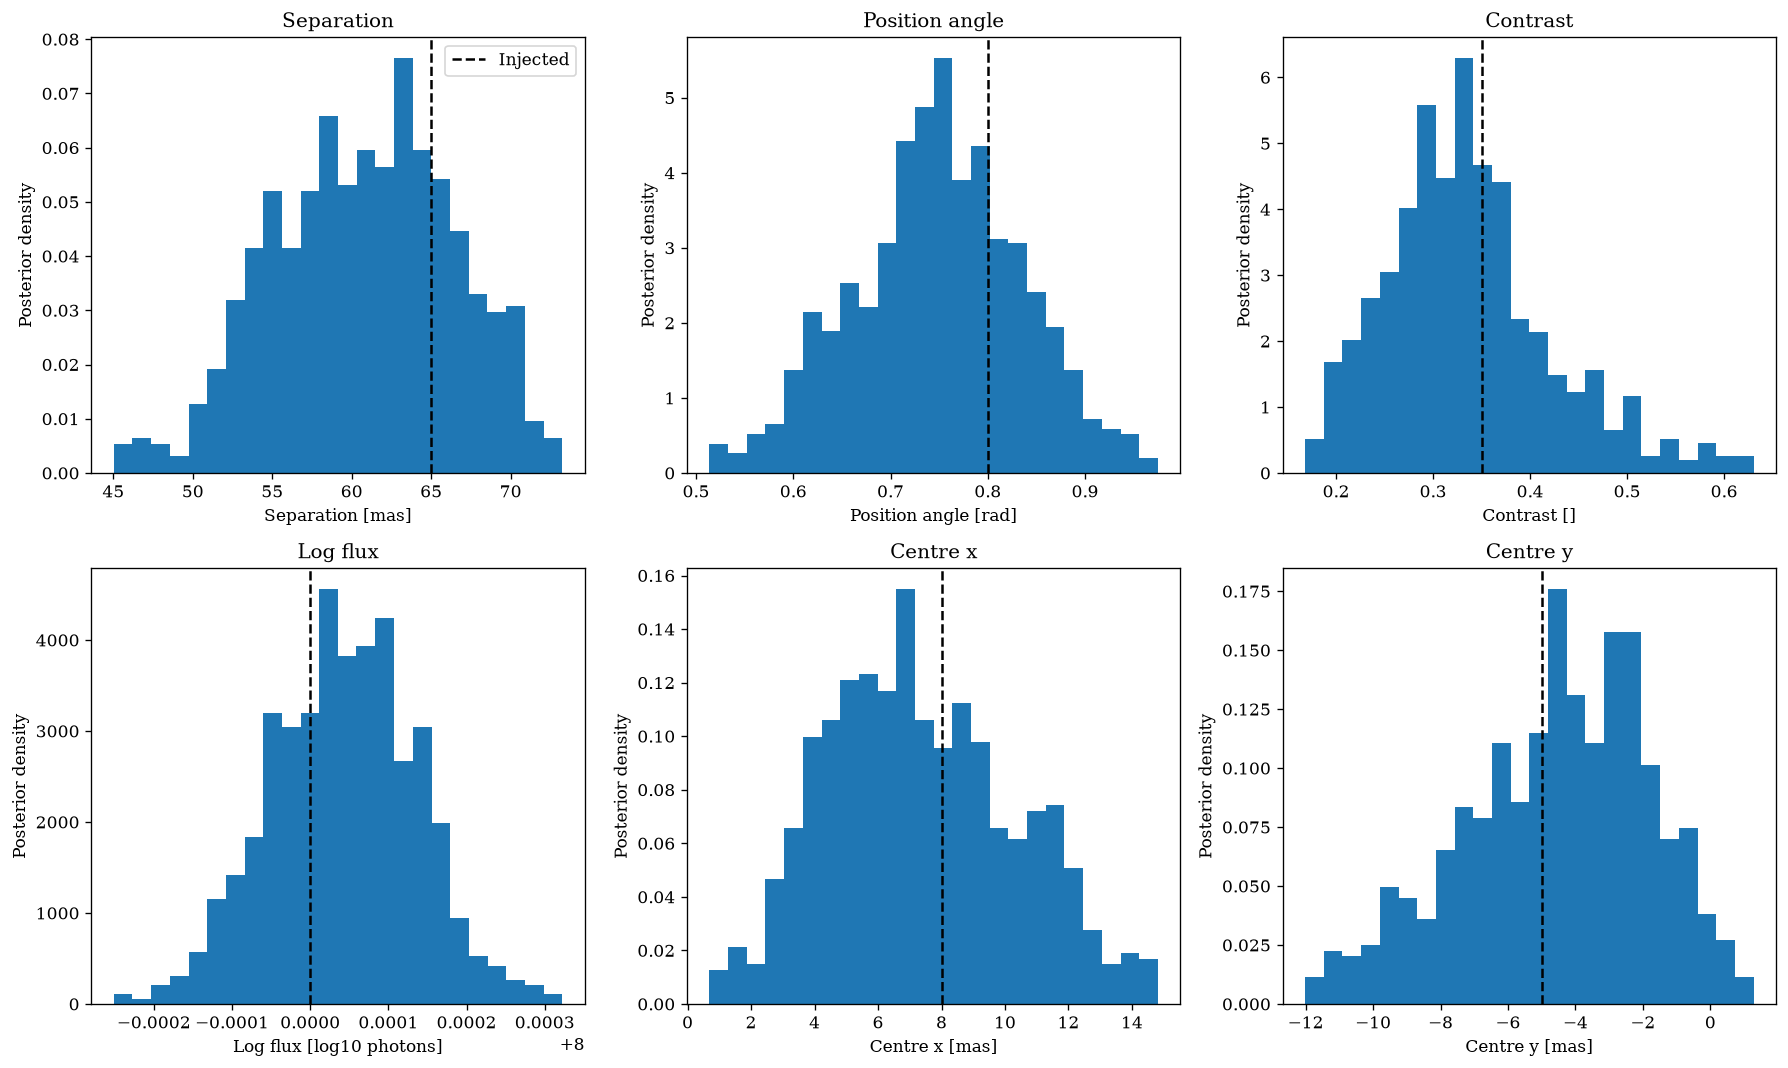

In [8]:
## COLLAPSE: Plotting code
def physical_fn(latent):
    params = unpack(project(latent))
    return np.array(
        [
            params["separation"],
            params["position_angle"],
            params["contrast"],
            params["flux"],
            *params["centre"],
        ]
    )


# Transform latent samples back into the physical source coordinates
samples = jax.vmap(jax.vmap(physical_fn))(chain_samples)
samples = samples.reshape(-1, samples.shape[-1])
truth = np.array([65.0, 0.8, 0.35, 8.0, 8.0, -5.0])
names = ["Separation", "Position angle", "Contrast", "Log flux", "Centre x", "Centre y"]
units = ["mas", "rad", "", "log10 photons", "mas", "mas"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, ax in enumerate(axes.ravel()):
    ax.hist(samples[:, i], bins=24, density=True)
    ax.axvline(truth[i], color="k", ls="--", label="Injected")
    ax.set(title=names[i], xlabel=f"{names[i]} [{units[i]}]", ylabel="Posterior density")
axes[0, 0].legend()
fig.tight_layout()
plt.show()


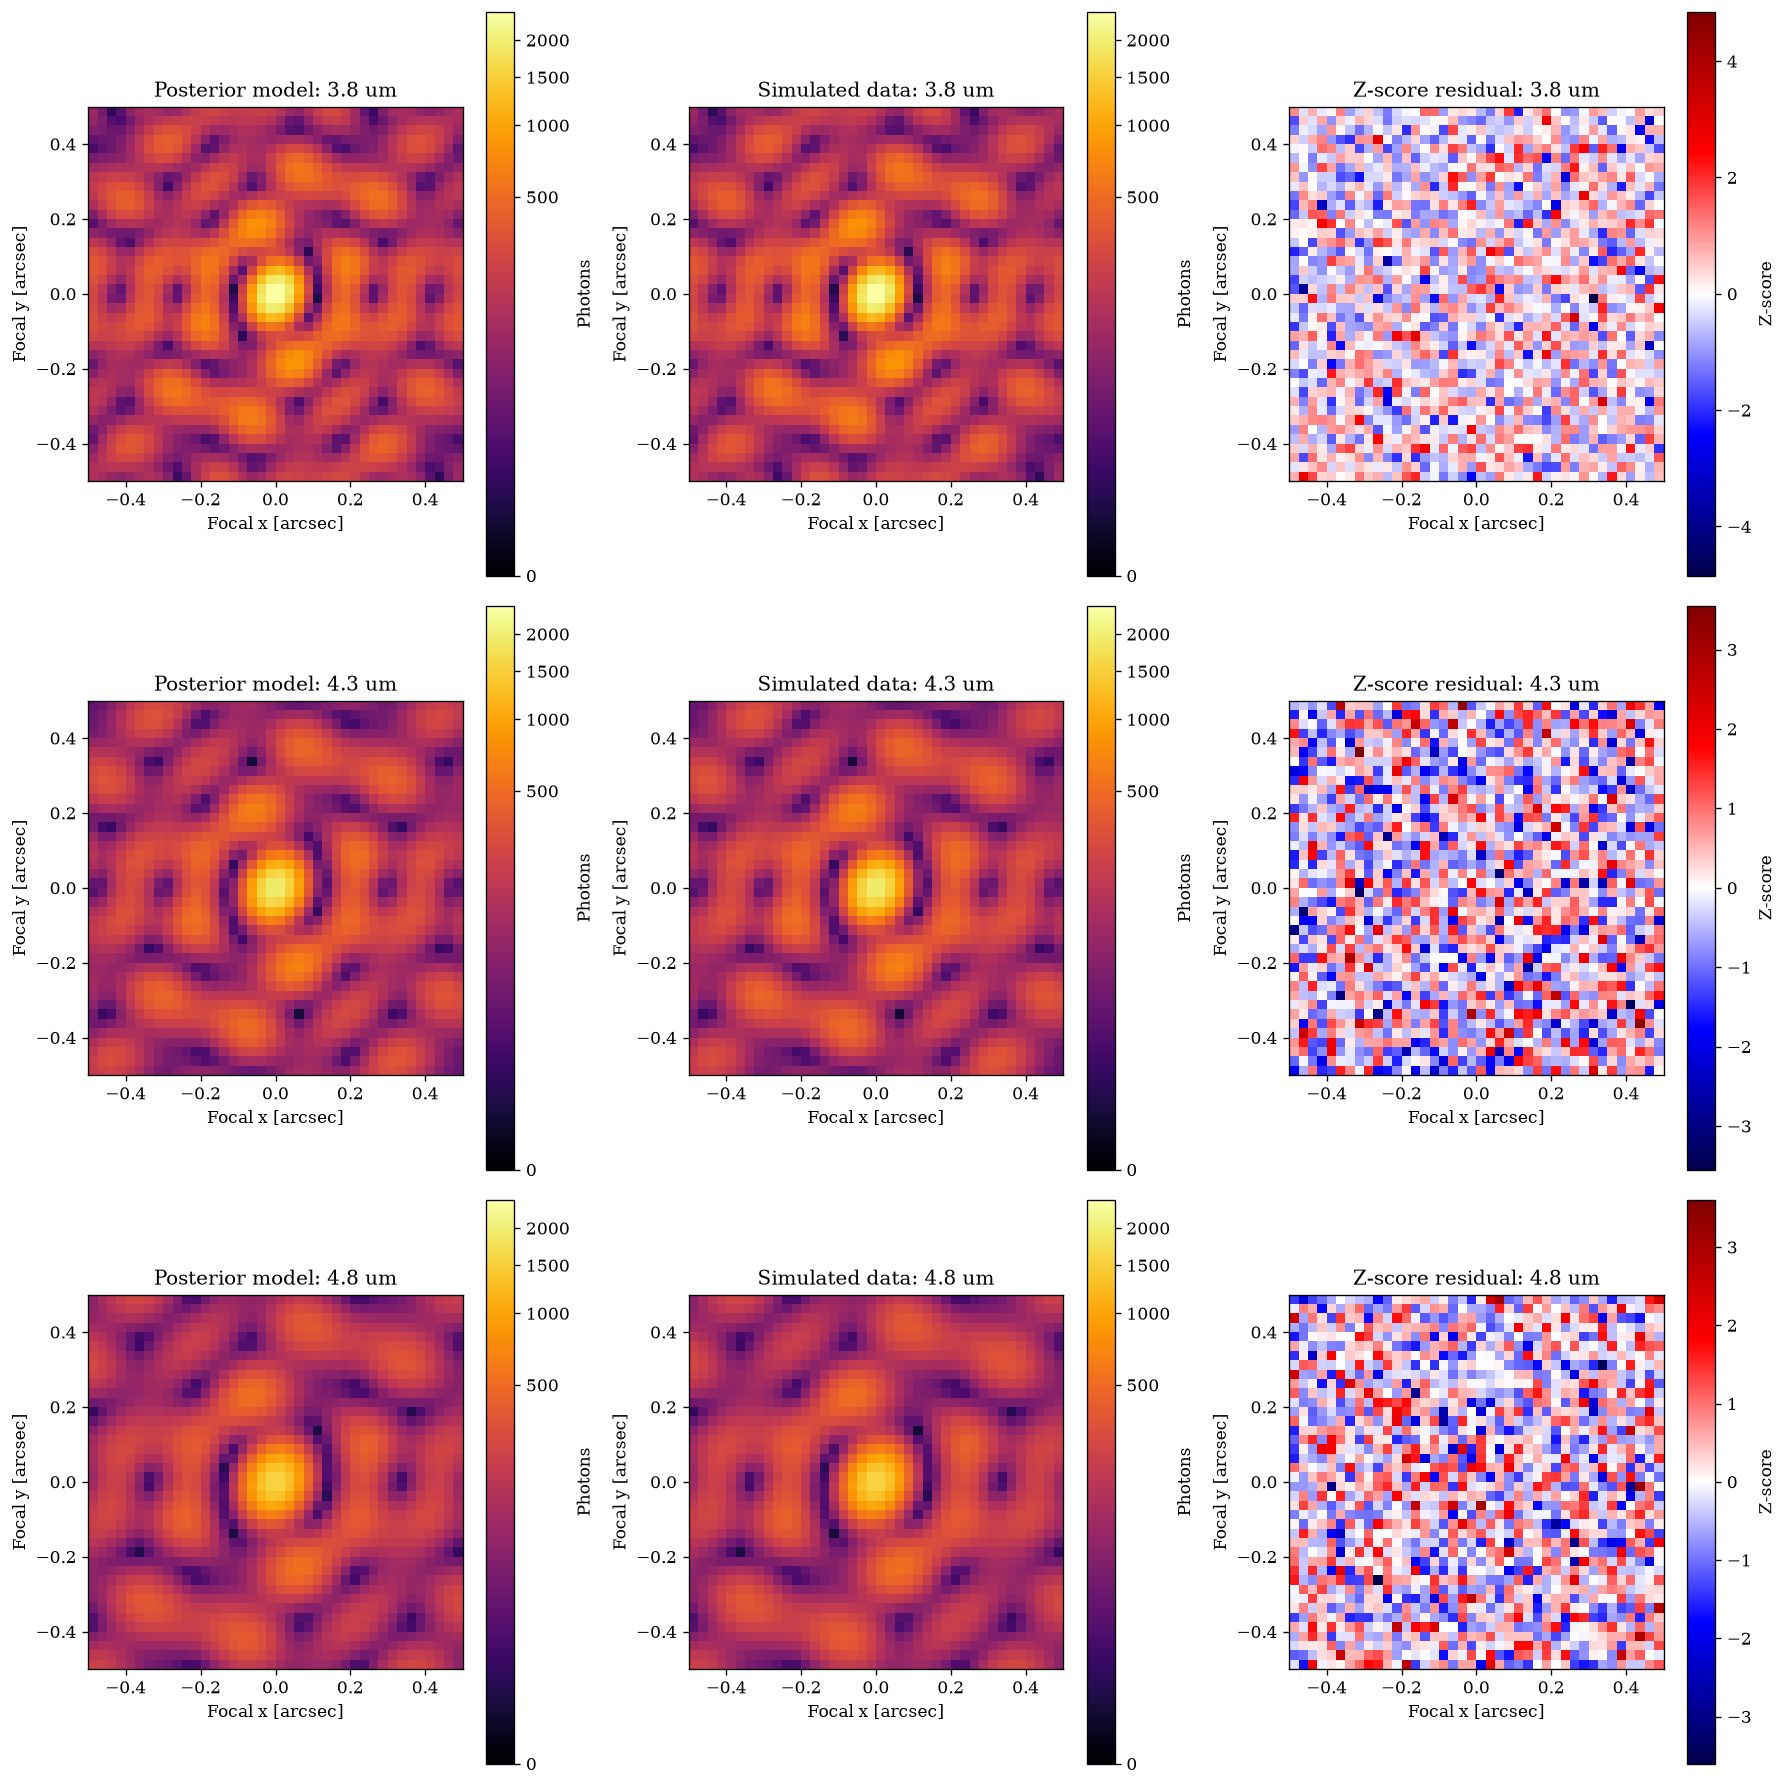

In [9]:
## COLLAPSE: Plotting code
# Evaluate the posterior-median model in every wavelength channel
median = np.median(samples, axis=0)
median_values = np.array(
    [median[0], median[1], np.log(median[2]), median[3], median[4], median[5]]
)
median_values = (median_values - offset) / scale
prediction = model_fn(median_values)
z_score = zdx.z_score(prediction, data, error)
extent = focal_grid.extent(ndim=2, unit="arcsec")
norm = PowerNorm(0.25, vmin=0, vmax=data.max())

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for i, wavelength in enumerate(wavelengths):
    panels = [prediction[i], data[i], z_score[i]]
    titles = ["Posterior model", "Simulated data", "Z-score residual"]
    maps = [cmaps["intensity"], cmaps["intensity"], cmaps["residual"]]
    norms = [norm, norm, CenteredNorm()]
    for ax, image, title, cmap, panel_norm in zip(axes[i], panels, titles, maps, norms):
        artist = ax.imshow(image, cmap, extent=extent, norm=panel_norm)
        ax.set(
            title=f"{title}: {wavelength:.1f} um",
            xlabel="Focal x [arcsec]",
            ylabel="Focal y [arcsec]",
        )
        label = "Photons" if title != "Z-score residual" else "Z-score"
        fig.colorbar(artist, ax=ax, label=label)
fig.tight_layout()
plt.show()


The calibrated dynamic aperture and the science inference remain
separate: `dynamic sparse optic → polynomial calibration → static sparse optic →
binary HMC`. Spectral diversity breaks much of the monochromatic NRM ambiguity, while
the fitted Gauss–Newton projection makes the mixed physical parameters tractable for
NUTS. The split-\(\hat R\), effective sample sizes, divergence count, injected-value
comparison, and posterior-predictive z-scores must all be inspected before treating
the samples as a recovered posterior.
